In [16]:
import pandas as pd

df=pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv')

In [17]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

In [18]:
training_size = round(len(df ) * 0.80)
print(training_size)
X_train=df[:training_size]
X_test=df[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=df[:training_size]
y_test=df[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [19]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    #print(i)
   
    for td in trends:
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(df)-1)
        #print(y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit incr

Lag=1,Trend=n
RMSE-Testset: 149.25670935726197
MAPE-Testset: 0.3298121789728311
************
Lag=1,Trend=t
RMSE-Testset: 113.21125306638295
MAPE-Testset: 0.2554180720641457
************
Lag=1,Trend=c
RMSE-Testset: 88.67744444547725
MAPE-Testset: 0.17921224372243946
************
Lag=1,Trend=ct
RMSE-Testset: 73.80096705180868
MAPE-Testset: 0.13976148134628577
************
Lag=2,Trend=n
RMSE-Testset: 145.1515684396974
MAPE-Testset: 0.32357415753474406
************
Lag=2,Trend=t
RMSE-Testset: 102.37156076772605
MAPE-Testset: 0.22798955731690315
************
Lag=2,Trend=c
RMSE-Testset: 113.0397696967979
MAPE-Testset: 0.2025585001966432
************
Lag=2,Trend=ct
RMSE-Testset: 68.30494114626069
MAPE-Testset: 0.11310707329550759
************
Lag=3,Trend=n
RMSE-Testset: 126.10867643186407
MAPE-Testset: 0.2815659007297645
************
Lag=3,Trend=t
RMSE-Testset: 100.69954681726641
MAPE-Testset: 0.22517796691740732
************
Lag=3,Trend=c
RMSE-Testset: 90.4234110572544
MAPE-Testset: 0.164490

C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\s

In [20]:
import numpy as np
i=4
td='ct'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(df)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=np.sqrt(mean_squared_error(y_test, y_pred))
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=4,Trend=ct
RMSE-Testset: 64.72116247153234
MAPE-Testset: 0.10140847785284221
************


C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [21]:
forecast=model_fit.predict(len(df), len(df)+3)
forecast

C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


1961-01-01    463.350960
1961-02-01    466.518375
1961-03-01    469.430513
1961-04-01    472.050982
Freq: MS, dtype: float64

<Figure size 1000x500 with 0 Axes>

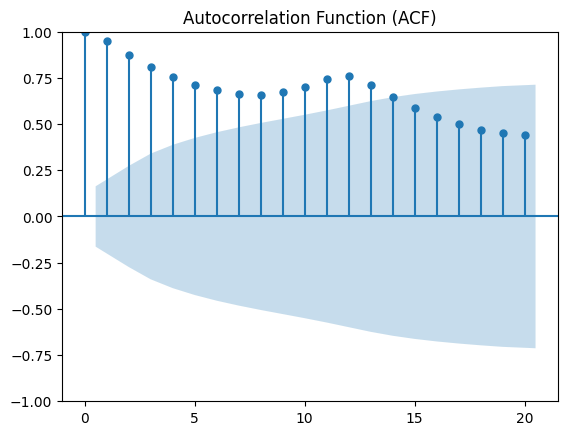

<Figure size 1000x500 with 0 Axes>

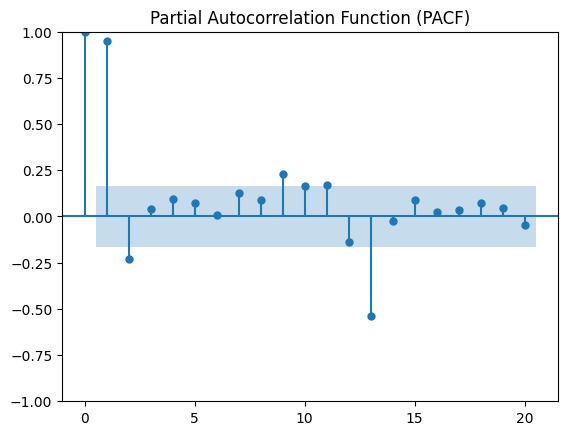

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Time series column
ts = df['Passengers']

# Plot ACF
plt.figure(figsize=(10,5))
plot_acf(ts, lags=20)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Plot PACF
plt.figure(figsize=(10,5))
plot_pacf(ts, lags=20, method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()


In [26]:
orders=[(1,1,1),(1,1,2),(2,3,1),(2,2,2)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(df, order=i)
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(0, len(df)-1)
    #print(y_pred)
    from stockFunctions import rmsemape
    rmsemape(df,y_pred)

C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was p

RMSE-Testset: 32.294433905961355
MAPE-Testset: 0.09272350078851734
RMSE-Testset: 31.153217724006034
MAPE-Testset: 0.08986550653335157
RMSE-Testset: 39.92413309510375
MAPE-Testset: 0.10916816519685289


C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\babuk\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


RMSE-Testset: 32.591880346558035
MAPE-Testset: 0.09657946785464068


In [31]:
forecast=model_fit.predict(len(df), len(df)+11)

In [32]:
forecast

1961-01-01    475.905226
1961-02-01    463.418180
1961-03-01    477.261298
1961-04-01    472.895356
1961-05-01    479.772004
1961-06-01    479.499208
1961-07-01    483.737006
1961-08-01    485.123045
1961-09-01    488.311051
1961-10-01    490.360260
1961-11-01    493.129130
1961-12-01    495.443207
Freq: MS, Name: predicted_mean, dtype: float64

In [33]:
import pandas as pd

df1=pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv')

In [34]:
df1

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


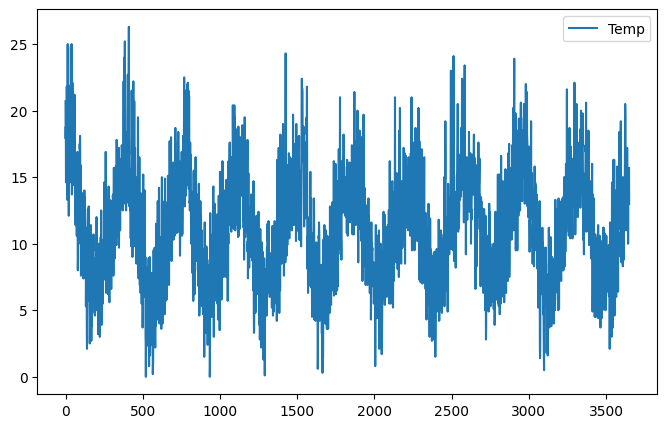

In [36]:
df1.plot(figsize=(8,5))
plt.show()

In [37]:
df1['Date'] = pd.to_datetime(df1['Date'])

# Extract the month number (1–12)
df1['Month'] = df1['Date'].dt.month

# Calculate monthly mean
monthly_mean = df1.groupby('Month')['Temp'].mean()

print(monthly_mean)

Month
1     15.030323
2     15.373759
3     14.565484
4     12.088333
5      9.866452
6      7.278333
7      6.692581
8      7.891290
9      8.976333
10    10.309355
11    12.479667
12    13.851948
Name: Temp, dtype: float64
